토큰화 진행 중...
Word2Vec 학습 시작...
[Epoch 1/10] 완료 | 소요시간: 9.00s
[Epoch 2/10] 완료 | 소요시간: 8.99s
[Epoch 3/10] 완료 | 소요시간: 9.11s
[Epoch 4/10] 완료 | 소요시간: 9.10s
[Epoch 5/10] 완료 | 소요시간: 9.20s
[Epoch 6/10] 완료 | 소요시간: 9.24s
[Epoch 7/10] 완료 | 소요시간: 9.01s
[Epoch 8/10] 완료 | 소요시간: 8.96s
[Epoch 9/10] 완료 | 소요시간: 8.93s
[Epoch 10/10] 완료 | 소요시간: 9.06s


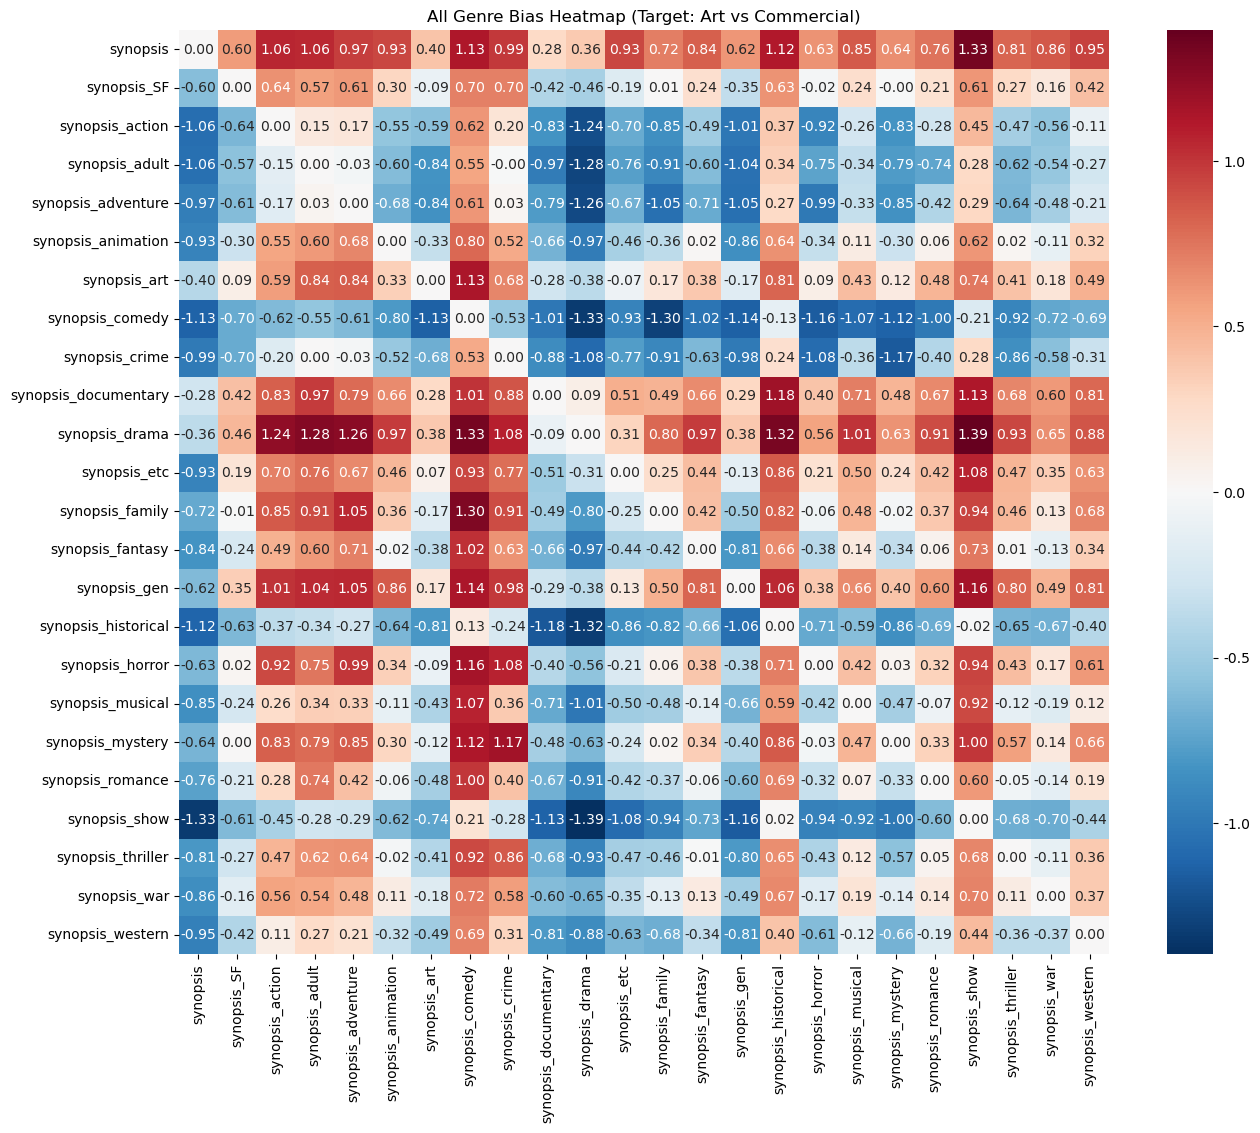

In [8]:
import re
import os
import time
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from konlpy.tag import Okt
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

# ---------------------------------
# STEP 1 & 2. 데이터 로드, 형태소 분석 및 Embedding 모델 만들기
# ---------------------------------
data_dir = "/home/jovyan/work/weat/data"
texts, genres = [], []

if os.path.exists(data_dir):
    for file in os.listdir(data_dir):
        if file.endswith(".txt"):
            genre = file.replace(".txt", "")
            path = os.path.join(data_dir, file)
            with open(path, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if line:
                        texts.append(line)
                        genres.append(genre)
else:
    print(f"경고: {data_dir} 경로가 존재하지 않습니다.")

df = pd.DataFrame({"synopsis": texts, "genre": genres})

# 명사 추출 함수
okt = Okt()
stopwords = {"영화", "이야기", "사람", "그", "그녀", "것", "수", "등", "때", "후", "전", "속", "한", "두", "세", "네", "위", "등장", "시작", "과정", "사건", "인간", "사회", "세계", "자신", "서로", "모든", "하나", "마음", "관계", "모습", "이들", "가운데"}

def extract_nouns(text):
    if not text: return []
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)
    nouns = okt.nouns(text)
    return [w for w in nouns if len(w) >= 2 and w not in stopwords and not w.isdigit()]

print("토큰화 진행 중...")
df["tokens"] = df["synopsis"].apply(extract_nouns)
df = df[df["tokens"].map(len) > 0].reset_index(drop=True)

# Word2Vec 학습
class EpochLogger(CallbackAny2Vec):
    def __init__(self, total):
        self.epoch = 0
        self.total = total
    def on_epoch_begin(self, model):
        self.start = time.time()
    def on_epoch_end(self, model):
        print(f"[Epoch {self.epoch+1}/{self.total}] 완료 | 소요시간: {time.time()-self.start:.2f}s")
        self.epoch += 1

print("Word2Vec 학습 시작...")
w2v_model = Word2Vec(sentences=df["tokens"].tolist(), vector_size=100, window=5, min_count=3, workers=4, sg=1, epochs=10, callbacks=[EpochLogger(10)])

# ---------------------------------
# STEP 3. Target 및 Attribute 단어 셋 만들기
# ---------------------------------
df["token_str"] = df["tokens"].apply(lambda x: " ".join(x))

def build_wordsets(df, group_col, topn_final=20):
    docs = df["token_str"].tolist()
    # 0점 방지를 위해 min_df를 유연하게 조정 (최소 2개 문서 등장)
    vectorizer = TfidfVectorizer(tokenizer=str.split, lowercase=False, min_df=2, max_df=0.6, token_pattern=None)
    X = vectorizer.fit_transform(docs)
    vocab = np.array(vectorizer.get_feature_names_out())
    group_names = sorted(df[group_col].dropna().unique())
    w2v_vocab = set(w2v_model.wv.index_to_key)

    group_candidates = {}
    for g in group_names:
        idx = df.index[df[group_col] == g].tolist()
        out_idx = df.index[df[group_col] != g].tolist()
        in_mean = np.asarray(X[idx].mean(axis=0)).ravel()
        out_mean = np.asarray(X[out_idx].mean(axis=0)).ravel() if out_idx else np.zeros_like(in_mean)
        
        score = in_mean - out_mean # 차별성 점수
        top_indices = score.argsort()[::-1]
        candidates = []
        for i in top_indices:
            word = vocab[i]
            if score[i] <= 0: break
            if word in w2v_vocab: candidates.append(word)
            if len(candidates) >= 100: break # 후보군 넉넉히 확보
        group_candidates[g] = candidates

    # 중복 제거 및 최종 선택
    word_group_count = Counter()
    for items in group_candidates.values():
        for word in items: word_group_count[word] += 1

    selected_words_global = set()
    final_wordsets = {}
    for g in group_names:
        final_list = []
        for word in group_candidates[g]:
            if word_group_count[word] >= max(3, len(group_names)//2): continue
            if word in selected_words_global: continue
            final_list.append(word)
            if len(final_list) >= topn_final: break
        final_wordsets[g] = final_list
        selected_words_global.update(final_list)
    return final_wordsets

# [Attribute 구축] 모든 장르 단어 셋
attribute_words = build_wordsets(df, "genre", topn_final=20)

# [Target 구축] 예술영화(X) vs 상업영화(Y) 단어 셋
# 데이터에 구분이 없다면 아래 핵심 단어를 기준으로 Word2Vec 필터링하여 구축
target_X_raw = ['예술', '독립', '철학', '감독', '메시지', '작품', '실험', '사회', '비판', '인생', '의미']
target_Y_raw = ['상업', '흥행', '오락', '대중', '스타', '자본', '기획', '배급', '시스템', '성공', '인기']

target_X = [w for w in target_X_raw if w in w2v_model.wv]
target_Y = [w for w in target_Y_raw if w in w2v_model.wv]

# ---------------------------------
# STEP 4. WEAT score 계산과 시각화
# ---------------------------------
def cos_sim(v1, v2):
    return cosine_similarity([v1], [v2])[0][0]

def s_word(w_vec, A_list, B_list):
    # 각 속성 단어들의 벡터 평균과의 거리 차이 계산
    vecs_A = [w2v_model.wv[a] for a in A_list if a in w2v_model.wv]
    vecs_B = [w2v_model.wv[b] for b in B_list if b in w2v_model.wv]
    if not vecs_A or not vecs_B: return 0.0
    res_A = np.mean([cos_sim(w_vec, a) for a in vecs_A])
    res_B = np.mean([cos_sim(w_vec, b) for b in vecs_B])
    return res_A - res_B

def weat_score(X_list, Y_list, A_list, B_list):
    vecs_X = [w2v_model.wv[x] for x in X_list]
    vecs_Y = [w2v_model.wv[y] for y in Y_list]
    if not vecs_X or not vecs_Y: return 0.0
    s_X = [s_word(x, A_list, B_list) for x in vecs_X]
    s_Y = [s_word(y, A_list, B_list) for y in vecs_Y]
    std_val = np.std(np.concatenate([s_X, s_Y]))
    return (np.mean(s_X) - np.mean(s_Y)) / std_val if std_val > 1e-8 else 0.0

# Matrix 생성
genre_names = [g for g, w in attribute_words.items() if len(w) > 0]
matrix = np.zeros((len(genre_names), len(genre_names)))

for i in range(len(genre_names)):
    for j in range(len(genre_names)):
        if i == j: continue
        matrix[i][j] = weat_score(target_X, target_Y, attribute_words[genre_names[i]], attribute_words[genre_names[j]])

# Heatmap 시각화
plt.figure(figsize=(15, 12))
plt.rc('font', family='sans-serif') # 한글 깨짐 방지용 (필요시 Malgun Gothic 등 수정)
plt.rcParams['axes.unicode_minus'] = False 
sns.heatmap(matrix, xticklabels=genre_names, yticklabels=genre_names, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('All Genre Bias Heatmap (Target: Art vs Commercial)')
plt.show()

## Data load, Tockenizing, Embedding, Attribute & Target
### 1. 데이터 로드 및 전처리  
- 지정된 디렉토리 내의 모든 .txt 파일을 읽어오기
- 이때 파일명을 genre로 사용함으로써 별도의 라벨링 작업 없이 자동으로 데이터를 분류
  
### 2. 형태소 분석 및 토큰화 (extract_nouns)  
- 단순한 텍스트를 분석 가능한 '단어' 단위로 쪼개는 과정  
- 특수문자 제거: re.sub를 사용하여 한글, 영문, 숫자 외의 잡음을 제거  
- 명사 추출: Okt.nouns를 사용하여 문장에서 핵심 의미를 담고 있는 명사만 골라냄.  

### 3. Word2Vec 학습 (w2v_model)
- 단어를 고차원 공간상의 벡터로 변환하는 핵심 단계(Embedding)  
- 의미적 유사도: sg=1 (Skip-gram) 방식을 사용하여 주변 단어를 통해 중심 단어의 의미를 파악
  
### 4. Target, Attribute words 지정
- 기존의 TF-IDF에서의 고질적인 문제점인 '흔하고 의미 없는 단어 문제', '모호한 개념 문제', '의미 없는 숫자/불용어 필터링'을 해결하고자 다음의 솔루션을 이용
  
① 차별성 점수 (In-mean - Out-mean) 
- 단순히 특정 장르에서 많이 나오는 단어를 뽑는 게 아니라, "다른 장르에 비해 이 장르에서 유독 많이 나오는가?"**를 계산  
- in_mean: 해당 장르 내의 평균 TF-IDF 점수  
- out_mean: 그 외 나머지 모든 장르에서의 평균 점수  
- 이 차이값이 클수록 그 장르만의 고유한 특성을 담은 단어가 됨.
  
② Word2Vec 단어장 확인  
- TF-IDF 점수가 아무리 높아도 Word2Vec 모델에 학습되지 않은 단어(너무 드물게 등장한 단어 등)는 나중에 편향성 계산을 할 수 없다.
- 이를 해결하기 위해 if word in w2v_vocab 조건을 통해 계산 가능한 단어만 안전하게 선별  
  
③ 전역 중복 및 흔한 단어 제거  
- 중복 제거: '액션' 장르에서 이미 대표 단어로 뽑힌 단어가 '범죄' 장르에서 또 뽑히지 않도록  selected_words_global 세트를 사용해 관리
- 기존 코드
```
def build_wordsets_simple(df, group_col, topn_final=20):
    # 1. TF-IDF 계산 (일반적인 설정)
    vectorizer = TfidfVectorizer(tokenizer=str.split, lowercase=False)
    X = vectorizer.fit_transform(df["token_str"])
    vocab = np.array(vectorizer.get_feature_names_out())
    group_names = sorted(df[group_col].dropna().unique())

    final_wordsets = {}

    for g in group_names:
        # 해당 장르의 문서 인덱스만 가져오기
        idx = df.index[df[group_col] == g].tolist()
        
        # ---------------------------------------------------------
        # ① 차별성 점수 없음: 그냥 해당 장르의 평균 점수만 계산
        # ---------------------------------------------------------
        group_mean = np.asarray(X[idx].mean(axis=0)).ravel()
        
        # 점수가 높은 순으로 정렬
        top_indices = group_mean.argsort()[::-1]
        
        final_list = []
        for i in top_indices:
            word = vocab[i]
            
            # ---------------------------------------------------------
            # ② Word2Vec 확인 없음: 그냥 단어 추가
            # ③ 전역 중복 제거 없음: 다른 장르에서 썼는지 검사 안 함
            # ---------------------------------------------------------
            final_list.append(word)
            
            if len(final_list) >= topn_final:
                break
        
        final_wordsets[g] = final_list
        
    return final_wordsets
```
### 5. 시각화 및 계산 수행 결과
1. 뚜렷한 예술 영화 장르(Red)는 드라마와 다큐멘터리가 차지했다.

2. 상업영화 성향 장르는 애니메이션, 코미디, 공포 및 스릴러 등이 차지했다.


## 오늘의 회고  
처음으로 NLP 분야에서 프로젝트를 진행해보았다.  
이번 프로젝트를 진행하면서 NLP의 전반적인 모델 구조에 대해 파악할 수 있었고, 지금까지 배웠던 이론 내용들이 머리 속에서 정리되었다.  
또한 TF-IDF를 이용해 Target, Attribute를 지정하는 과정에서 TF-IDF의 고질적인 한계를 해결하기 위해 다양한 시도를 해보며 응용하는 방법을 익힐 수 있었다.  
오늘은 임베딩까지만 학습을 하여 결과를 비교하였지만, 다음에 RNN과 CNN을 이용한 프로젝트 및 실습을 수행할 때 결과가 어떻게 달라지는지 궁금해졌다.